# Telco Customer Churn Prediction

Predicting customer churn for a telecom company using classical ML models.
Comparing logistic regression, random forest, and XGBoost.

**Dataset:** Telco Customer Churn (Kaggle, 7,043 customers, 21 features)
**Target:** `Churn` (Yes/No) — binary classification

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory data analysis

In [2]:
# Basic info about each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# TotalCharges is stored as text — convert to numeric
# Some rows have empty strings, which pd.to_numeric will turn into NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# How many missing values do we have now?
print(f"Missing TotalCharges: {df['TotalCharges'].isna().sum()}")

# These 11 rows are customers with tenure = 0 (brand new), so TotalCharges is empty
# We'll drop them since they're a tiny fraction and may not represent real churn behavior
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
print(f"Shape after cleaning: {df.shape}")

Missing TotalCharges: 11
Shape after cleaning: (7032, 21)


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn rate: 26.58%


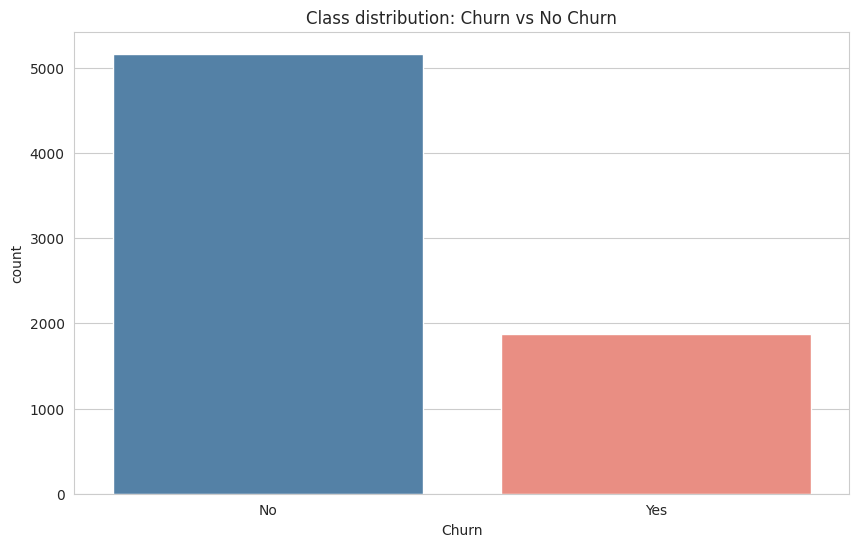

In [4]:
# What's the class balance?
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

# Visualize it
sns.countplot(data=df, x="Churn", hue="Churn", palette=["steelblue", "salmon"], legend=False)
plt.title("Class distribution: Churn vs No Churn")
plt.show()

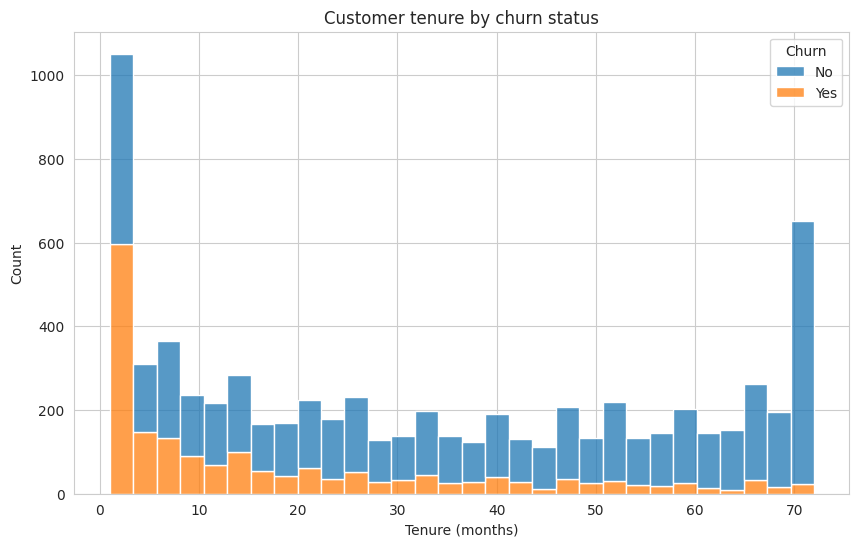

In [5]:
# How does tenure relate to churn?
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30)
plt.title("Customer tenure by churn status")
plt.xlabel("Tenure (months)")
plt.show()

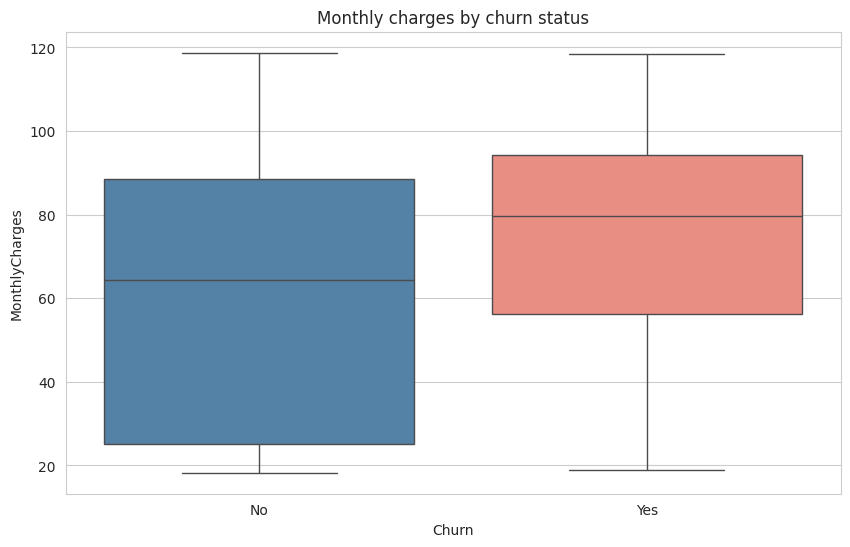

In [6]:
# Monthly charges vs churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", palette=["steelblue", "salmon"], legend=False)
plt.title("Monthly charges by churn status")
plt.show()

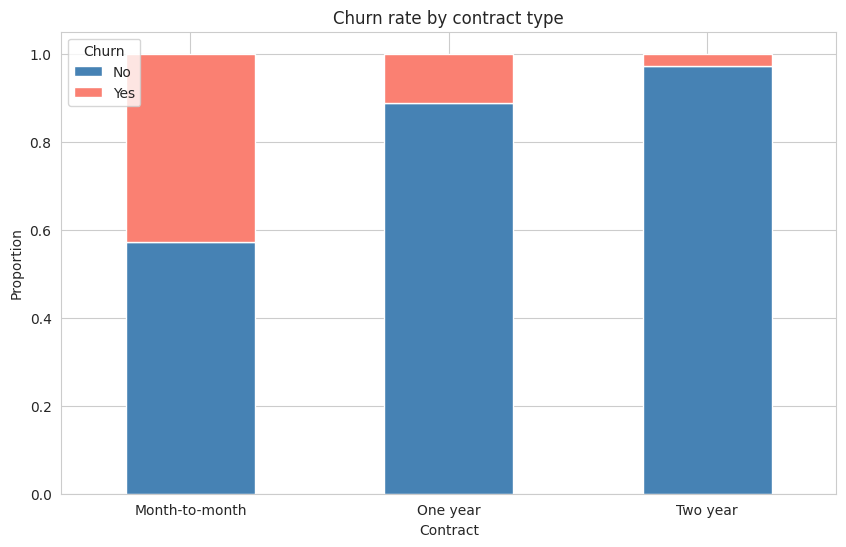

In [7]:
# Churn rate by contract type
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()
contract_churn.plot(kind="bar", stacked=True, color=["steelblue", "salmon"], figsize=(10, 6))
plt.title("Churn rate by contract type")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()